# Four-bar comparison & fine-tune

You enter **two** four-bar configurations - an *initial* (reference) and
a *modified* (candidate). For each one the notebook simulates the
path-node trace and prints the MotionGen JSON. Then the fine-tuner
starts from the **modified** PSlice and tries to make its path-node
trace match the **initial** trace.

The optimized mechanism is **shifted** (right or above) relative to the
initial - in both the matplotlib side-by-side view *and* the optimized
MotionGen JSON. Pasting the initial + optimized JSONs into MotionGen
back-to-back puts them in the same scene without overlap.

Topology (don't change unless you change the JJ):

| idx | role | description |
|-----|------|-------------|
| 0 | fixed | motor pivot |
| 1 | moving | driven crank tip |
| 2 | fixed | other ground pivot |
| 3 | moving | rocker joint |
| 4 | moving | **path node** (on the coupler triangle) |


## Setup


In [13]:
import os, sys, json, time, datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import torch

HERE = os.getcwd()
ARG_DIR = HERE if os.path.basename(HERE) == 'Argentina' else os.path.join(HERE, 'Argentina')
if ARG_DIR not in sys.path:
    sys.path.insert(0, ARG_DIR)

from simulator import sort_mechanism, simulate_batch_no_grad, reachable_arc
from optimizer import fit_to_expected_path, optimize_mechanism, normalize_curve, METRICS
from motiongen_export import build_motiongen_json, copy_to_clipboard
from visualizer import save_config_txt

DTYPE = torch.float64
print('ready - torch', torch.__version__, ', numpy', np.__version__)


ready - torch 2.11.0+cu128 , numpy 2.4.6


## Fixed topology (don't edit unless you change the JJ)


In [14]:
JJ = np.array([
    [0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1],
    [0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1],
    [0, 1, 0, 1, 0],
], dtype=int)
motor       = [0, 1]
fixed_nodes = [0, 2]
path_node   = 4
edges = [(0, 1), (1, 3), (2, 3), (1, 4), (3, 4)]


## 1. INITIAL four-bar - edit the 5x2 PSlice matrix

Each row is the initial (x, y) of one joint.


In [15]:
PSlice_initial = np.array([
    [0.0, 0.0],    # joint 0 - ground / motor pivot (fixed)
    [1.0, 2.0],    # joint 1 - driven crank tip
    [4.0, 0.0],    # joint 2 - other ground pivot (fixed)
    [3.0, 2.0],    # joint 3 - rocker
    [2.0, 3.0],    # joint 4 - path node
])


### Simulate INITIAL + MotionGen text


INITIAL reachable arc: mode=wrap, 89/200 samples (44%)


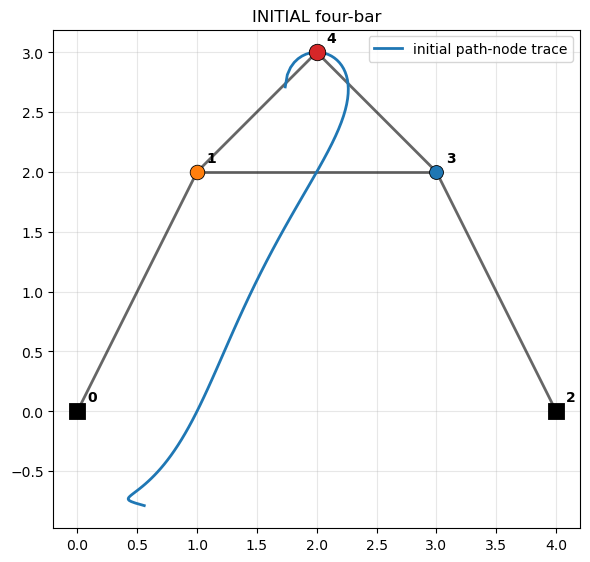


--- MotionGen JSON for INITIAL (2,742 chars) ---
clipboard: windows:Win32 SetClipboardData (CF_UNICODETEXT)
{"name":"motiongen","version":"1.1.5","mechanism":{"mode":"standard","joints":[{"id":"6bf180fb-a16f-4b25-af3d-2eefa2b4ce74","x":0.0,"y":0.0,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"e64c7f6f-9ac2-4e2b-b266-a1ebe90f6f2a","x":1.0,"y":2.0,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"68a26e72-bd91-4c5b-95fc-5eb6ef55da9c","x":4.0,"y":0.0,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"c6d1e266-c138-472e-a452-f3620aeae1e4","x":3.0,"y":2.0,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"3db05622-9d18-49de-a5b7-ee28070729b9","x"

In [16]:
def simulate_path(PSlice_, n_theta=200):
    JJ_s, PS_s, _, fn_s, ord_ = sort_mechanism(JJ, PSlice_, motor, fixed_nodes)
    N = JJ_s.shape[0]
    n_t = np.zeros([N, 1]);  n_t[fn_s] = 1
    JJs   = torch.as_tensor(JJ_s[None],   dtype=DTYPE)
    PSls  = torch.as_tensor(PS_s[None],   dtype=DTYPE)
    nts   = torch.as_tensor(n_t[None],    dtype=DTYPE)
    ths   = torch.linspace(0, 2 * np.pi, n_theta + 1, dtype=DTYPE)[:n_theta]
    sol   = simulate_batch_no_grad(JJs, PSls, nts, ths)[0].cpu().numpy()
    inv = np.empty_like(ord_); inv[ord_] = np.arange(N)
    sol_o = sol[inv]
    return sol_o, sol_o[path_node]

def draw_mechanism(ax, PSlice_, x_shift=0.0, y_shift=0.0,
                   joint_alpha=1.0, link_alpha=0.6):
    PS = PSlice_.copy(); PS[:, 0] += x_shift; PS[:, 1] += y_shift
    for a, b in edges:
        ax.plot([PS[a, 0], PS[b, 0]], [PS[a, 1], PS[b, 1]],
                '-', color='black', lw=2, alpha=link_alpha)
    for k in range(PS.shape[0]):
        if k in fixed_nodes:
            col = 'black'; mk = 's'; sz = 120
        elif k == path_node:
            col = '#d62728'; mk = 'o'; sz = 140
        elif k == motor[1]:
            col = '#ff7f0e'; mk = 'o'; sz = 110
        else:
            col = '#1f77b4'; mk = 'o'; sz = 100
        ax.scatter(*PS[k], s=sz, marker=mk, color=col,
                   edgecolor='black', linewidths=0.6,
                   alpha=joint_alpha, zorder=5)
        ax.annotate(f'{k}', PS[k], xytext=(7, 7),
                    textcoords='offset points', fontsize=10, fontweight='bold')

def shift_pslice(PSlice_, dx=0.0, dy=0.0):
    P = PSlice_.copy(); P[:, 0] += dx; P[:, 1] += dy
    return P

_, trace_init = simulate_path(PSlice_initial)
arc_init, info_init = reachable_arc(trace_init)
print(f"INITIAL reachable arc: mode={info_init['mode']}, "
      f"{info_init['count']}/{trace_init.shape[0]} samples "
      f"({100*info_init['fraction']:.0f}%)")

fig, ax = plt.subplots(figsize=(6, 6))
draw_mechanism(ax, PSlice_initial)
ax.plot(arc_init[:, 0], arc_init[:, 1], '-', color='#1f77b4',
        lw=2.0, label='initial path-node trace')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('INITIAL four-bar')
plt.tight_layout(); plt.show()

mg_init = json.dumps(build_motiongen_json(JJ, PSlice_initial, motor, fixed_nodes, path_node),
                     separators=(',', ':'))
which = copy_to_clipboard(mg_init)
print(f"\n--- MotionGen JSON for INITIAL ({len(mg_init):,} chars) ---")
print(f"clipboard: {which if which else 'NOT copied; paste the text below manually'}")
print(mg_init)


## 2. MODIFIED four-bar - edit the 5x2 PSlice matrix

The starting point for fine-tuning.


In [17]:
PSlice_modified = np.array([
    [0.0, 0.0],    # joint 0
    [1.2, 1.8],    # joint 1
    [4.0, 0.0],    # joint 2
    [3.2, 1.7],    # joint 3
    [2.3, 3.2],    # joint 4
])


### Simulate MODIFIED + MotionGen text


MODIFIED reachable arc: mode=wrap, 79/200 samples (40%)


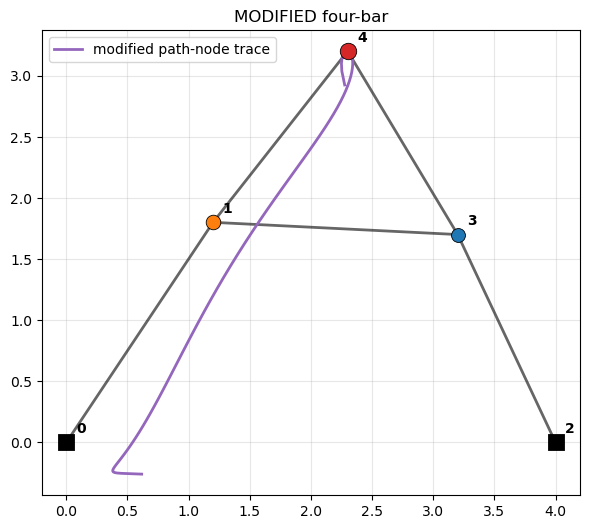


--- MotionGen JSON for MODIFIED (2,742 chars) ---
clipboard: windows:Win32 SetClipboardData (CF_UNICODETEXT)
{"name":"motiongen","version":"1.1.5","mechanism":{"mode":"standard","joints":[{"id":"a3736798-79a7-422e-bac0-a1f2b6283db2","x":0.0,"y":0.0,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"fa0fb8e0-17aa-4ba0-92ee-a15027f1d54c","x":1.2,"y":1.8,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"df0da731-689f-458e-953a-6d3675adda7e","x":4.0,"y":0.0,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"2fee9328-60fa-402b-a521-995652ad83a1","x":3.2,"y":1.7,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"0f0216e9-deb7-4ce5-8796-005a9b29a116","x

In [18]:
_, trace_mod = simulate_path(PSlice_modified)
arc_mod, info_mod = reachable_arc(trace_mod)
print(f"MODIFIED reachable arc: mode={info_mod['mode']}, "
      f"{info_mod['count']}/{trace_mod.shape[0]} samples "
      f"({100*info_mod['fraction']:.0f}%)")

fig, ax = plt.subplots(figsize=(6, 6))
draw_mechanism(ax, PSlice_modified)
ax.plot(arc_mod[:, 0], arc_mod[:, 1], '-', color='#9467bd',
        lw=2.0, label='modified path-node trace')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('MODIFIED four-bar')
plt.tight_layout(); plt.show()

mg_mod = json.dumps(build_motiongen_json(JJ, PSlice_modified, motor, fixed_nodes, path_node),
                    separators=(',', ':'))
which = copy_to_clipboard(mg_mod)
print(f"\n--- MotionGen JSON for MODIFIED ({len(mg_mod):,} chars) ---")
print(f"clipboard: {which if which else 'NOT copied; paste the text below manually'}")
print(mg_mod)


## 3. Pick the optimization metric(s)

Available metrics (from `optimizer.py`):
- `'ordered_l2'`  - point-wise L2 (matched sample order)
- `'mse'`         - mean of squared L2 distances
- `'chamfer'`     - hard bidirectional nearest-neighbor mean
- `'hausdorff'`   - one-sided max-min, both ways summed
- `'soft_chamfer'`- smooth bidirectional softmin (use with `tau_anneal=True`)
- `'soft_dtw'`    - Soft-DTW divergence (always >= 0)

Single metric or a list; `metric_weights` scales each entry of the list.

**Default**: `['soft_chamfer', 'hausdorff']` with weights `[1.0, 0.5]`,
`lr=0.1`, `n_outer=60`.

Combos worth trying:
| metrics | weights | when |
|---|---|---|
| `'soft_chamfer'` | n/a | smoothest single-metric baseline |
| `'hausdorff'` | n/a | minimize the worst-case deviation |
| `['soft_chamfer','hausdorff']` | `[1.0, 0.5]` | **default**; balanced |
| `['soft_chamfer','soft_dtw']` | `[1.0, 0.2]` | spatial + temporal alignment |
| `'soft_dtw'` | n/a | sequence-alignment-aware |


In [19]:
opt_metric         = ['soft_chamfer', 'hausdorff']
opt_metric_weights = [1.0, 0.5]
opt_lr             = 0.05
opt_n_outer        = 60
opt_tau_anneal     = True
print('metric        :', opt_metric)
print('weights       :', opt_metric_weights)
print('lr            :', opt_lr)
print('n_outer       :', opt_n_outer)
print('tau_anneal    :', opt_tau_anneal)


metric        : ['soft_chamfer', 'hausdorff']
weights       : [1.0, 0.5]
lr            : 0.05
n_outer       : 60
tau_anneal    : True


## 4. Fine-tune the modified config to match the initial path


In [20]:
t0 = time.perf_counter()
res = fit_to_expected_path(
    JJ, PSlice_modified, arc_init,
    motor=motor, fixed_nodes=fixed_nodes, path_node=path_node,
    method='lbfgs',
    metric=opt_metric, metric_weights=opt_metric_weights,
    n_outer=opt_n_outer, lr=opt_lr, tau_anneal=opt_tau_anneal,
    verbose=False,
)
elapsed = time.perf_counter() - t0
PSlice_optimized = res['x_optimized']
hist = res['history']
loss_drop = (hist[0] - hist[-1]) / max(abs(hist[0]), 1e-30) * 100
print(f"L-BFGS done: {len(hist)} outer steps, "
      f"loss {hist[0]:.4e} -> {hist[-1]:.4e} "
      f"({loss_drop:+.1f}% reduction)   {elapsed:.2f} s")

_, trace_opt = simulate_path(PSlice_optimized)
arc_opt, info_opt = reachable_arc(trace_opt)
print(f"OPTIMIZED reachable arc: mode={info_opt['mode']}, "
      f"{info_opt['count']}/{trace_opt.shape[0]} samples "
      f"({100*info_opt['fraction']:.0f}%)")


L-BFGS done: 60 outer steps, loss 2.1509e-01 -> 1.4068e-01 (+34.6% reduction)   2.03 s
OPTIMIZED reachable arc: mode=wrap, 80/200 samples (40%)


## 5. Pick the displacement direction

`direction` controls where the optimized mechanism sits relative to the
initial one. **Applied consistently to both the matplotlib view and the
optimized MotionGen JSON** so pasting both JSONs into MotionGen places
them where the picture shows.

| value | effect | dx, dy |
|---|---|---|
| `'right'` | optimized to the right of initial | `(>0, 0)` |
| `'top'`   | optimized above initial            | `(0, >0)` |
| `'none'`  | no shift (overlaid)                | `(0, 0)`  |

`displacement` is the shift magnitude; leave as `None` to auto-pick from
the mechanism's x or y extent (with a 30% gap).


In [21]:
direction    = 'right'   # 'right' | 'top' | 'none'
displacement = None      # None -> auto; or a float

def _auto_disp(PS_a, PS_b, axis, margin_frac=0.3):
    span_a = PS_a[:, axis].max() - PS_a[:, axis].min()
    span_b = PS_b[:, axis].max() - PS_b[:, axis].min()
    gap = max(span_a, span_b) * margin_frac
    return PS_a[:, axis].max() - PS_b[:, axis].min() + gap

if direction == 'right':
    dx = float(displacement) if displacement is not None \
            else _auto_disp(PSlice_initial, PSlice_optimized, axis=0)
    dy = 0.0
elif direction == 'top':
    dx = 0.0
    dy = float(displacement) if displacement is not None \
            else _auto_disp(PSlice_initial, PSlice_optimized, axis=1)
elif direction == 'none':
    dx = dy = 0.0
else:
    raise ValueError(f"direction must be 'right', 'top', or 'none'; got {direction!r}")
print(f'direction={direction}  dx={dx:.3f}  dy={dy:.3f}')


direction=right  dx=5.171  dy=0.000


## 6. Side-by-side visualization


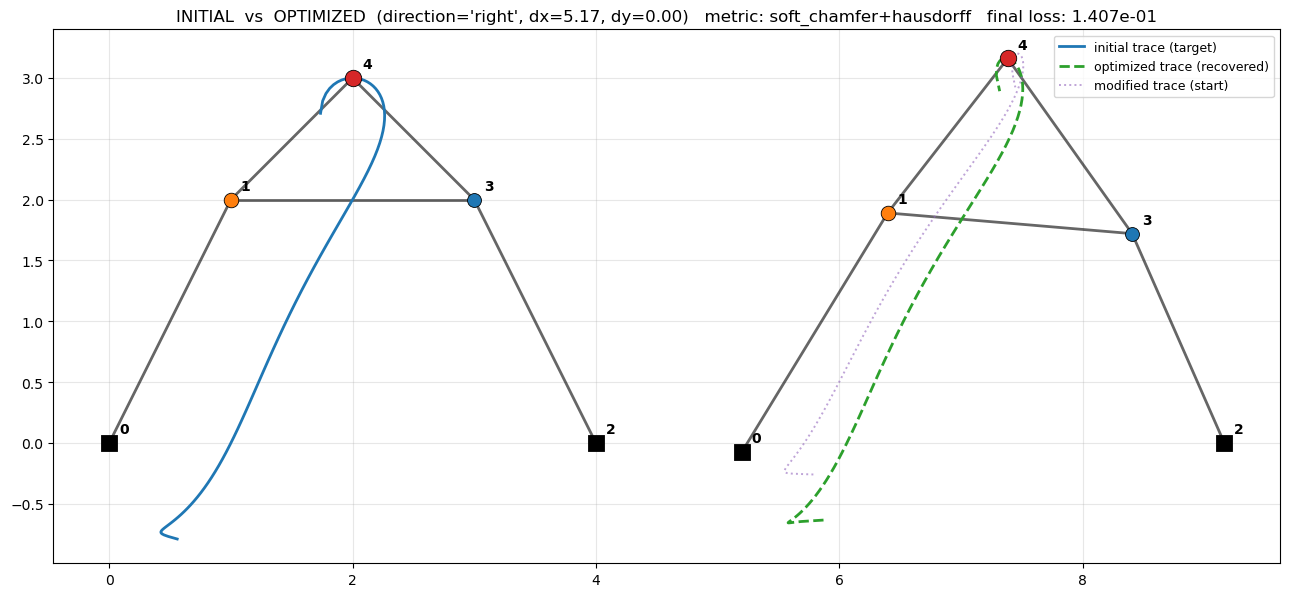

In [22]:
fig, ax = plt.subplots(figsize=(13, 6))

# Initial 4-bar at origin.
draw_mechanism(ax, PSlice_initial)
ax.plot(arc_init[:, 0], arc_init[:, 1], '-', color='#1f77b4',
        lw=2.0, label='initial trace (target)')

# Optimized 4-bar shifted by (dx, dy).
draw_mechanism(ax, PSlice_optimized, x_shift=dx, y_shift=dy)
arc_opt_shifted = arc_opt + np.array([dx, dy])
ax.plot(arc_opt_shifted[:, 0], arc_opt_shifted[:, 1], '--', color='#2ca02c',
        lw=2.0, label='optimized trace (recovered)')

# Modified (starting) trace, dotted alongside the optimized for "before" reference.
arc_mod_shifted = arc_mod + np.array([dx, dy])
ax.plot(arc_mod_shifted[:, 0], arc_mod_shifted[:, 1], ':',
        color='#9467bd', lw=1.4, alpha=0.6, label='modified trace (start)')

ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(loc='best', fontsize=9)
metric_label = (opt_metric if isinstance(opt_metric, str)
                else '+'.join(opt_metric))
ax.set_title(f"INITIAL  vs  OPTIMIZED  (direction='{direction}', "
             f"dx={dx:.2f}, dy={dy:.2f})   metric: {metric_label}   "
             f"final loss: {hist[-1]:.3e}")
plt.tight_layout(); plt.show()


## 7. Optimization history (error drop)


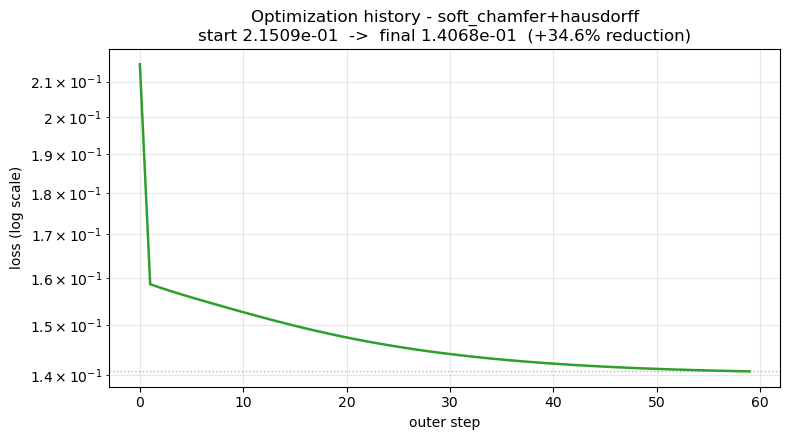

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(hist, lw=1.8, color='#2ca02c')
ax.set_xlabel('outer step'); ax.set_ylabel('loss (log scale)')
ax.set_title(f"Optimization history - {metric_label}\n"
             f"start {hist[0]:.4e}  ->  final {hist[-1]:.4e}  "
             f"({loss_drop:+.1f}% reduction)")
ax.grid(alpha=0.3, which='both')
ax.axhline(hist[-1], color='gray', ls=':', lw=1, alpha=0.6)
plt.tight_layout(); plt.show()


## 8. MotionGen JSON for the OPTIMIZED config (with displacement applied)

The PSlice coordinates baked into this JSON include the `(dx, dy)` shift
chosen above. Paste this **after** the INITIAL JSON in MotionGen and
they'll appear side-by-side / stacked as the picture shows.


In [24]:
PSlice_optimized_shifted = shift_pslice(PSlice_optimized, dx=dx, dy=dy)
mg_opt = json.dumps(build_motiongen_json(JJ, PSlice_optimized_shifted,
                                         motor, fixed_nodes, path_node),
                    separators=(',', ':'))
which = copy_to_clipboard(mg_opt)
print(f"--- MotionGen JSON for OPTIMIZED  (direction='{direction}', "
      f"dx={dx:.2f}, dy={dy:.2f},  {len(mg_opt):,} chars) ---")
print(f"clipboard: {which if which else 'NOT copied; paste the text below manually'}")
print(mg_opt)

# Save both the un-shifted and shifted PSlice as .txt configs.
#ts = dt.datetime.now().strftime('%Y%m%d_%H%M%S')
#out_txt_raw     = os.path.join(ARG_DIR, f'compare_optimized_{ts}.txt')
#out_txt_shifted = os.path.join(ARG_DIR, f'compare_optimized_shifted_{ts}.txt')
#save_config_txt(out_txt_raw,     JJ, PSlice_optimized,         motor, fixed_nodes, path_node)
#save_config_txt(out_txt_shifted, JJ, PSlice_optimized_shifted, motor, fixed_nodes, path_node)
#print(f"\nsaved unshifted: {out_txt_raw}")
#print(f"saved shifted  : {out_txt_shifted}")


--- MotionGen JSON for OPTIMIZED  (direction='right', dx=5.17, dy=0.00,  2,890 chars) ---
clipboard: windows:Win32 SetClipboardData (CF_UNICODETEXT)
{"name":"motiongen","version":"1.1.5","mechanism":{"mode":"standard","joints":[{"id":"f82e2b96-8703-4421-b798-59521ed6dbe8","x":5.199999999999999,"y":-0.07299469658870912,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"38ab4916-7526-4111-a192-4aa8caad9edf","x":6.398146967958763,"y":1.8908834281145344,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"393c8208-4d02-4e19-8e4e-e1c46ac52311","x":9.16432304926299,"y":0.0011807113719078468,"curveColor":"rgba(99, 179, 237, 1)","isShowCurve":true,"isShowArrows":false,"isWelded":false,"isSelected":true,"isLocked":false},{"id":"04b21710-3c08-4358-ae1d-84aae94a2e38","x":8.407326306329422,"y":1.7206839391190478,"curveColor":"rgba

## Done

The flow:
- INITIAL: mechanism + trace + MotionGen JSON (unshifted).
- MODIFIED: mechanism + trace + MotionGen JSON (unshifted).
- Pick `direction` and `displacement`.
- OPTIMIZED: shifted by `(dx, dy)` in both the matplotlib view and the
  MotionGen JSON, so pasting both JSONs into MotionGen places them
  exactly as the picture shows.

To experiment, edit any of:
- `PSlice_initial` (target shape)
- `PSlice_modified` (starting point)
- `opt_metric`, `opt_metric_weights`, `opt_lr`, `opt_n_outer`
- `direction`, `displacement`

and re-run from the affected cell down.
